# Step 1: Generation of the snapshots
This notebook generates

    Iter 010 | k_eff: 0.980102 | Rel Error: 3.022e-05
    Iter 020 | k_eff: 0.979846 | Rel Error: 1.822e-05
    Iter 030 | k_eff: 0.979763 | Rel Error: 3.893e-06
    Iter 040 | k_eff: 0.979742 | Rel Error: 1.315e-06
    Iter 050 | k_eff: 0.979734 | Rel Error: 6.433e-07
    Iter 060 | k_eff: 0.979729 | Rel Error: 3.560e-07
    Iter 070 | k_eff: 0.979726 | Rel Error: 2.027e-07
    Iter 080 | k_eff: 0.979725 | Rel Error: 1.160e-07
    Iter 090 | k_eff: 0.979724 | Rel Error: 6.633e-08
    Iter 100 | k_eff: 0.979724 | Rel Error: 3.787e-08
    Iter 110 | k_eff: 0.979723 | Rel Error: 2.158e-08
    Iter 120 | k_eff: 0.979723 | Rel Error: 1.228e-08
    Iter 130 | k_eff: 0.979723 | Rel Error: 6.976e-09
    Iter 140 | k_eff: 0.979723 | Rel Error: 3.960e-09
    Iter 150 | k_eff: 0.979723 | Rel Error: 2.246e-09
    Iter 160 | k_eff: 0.979723 | Rel Error: 1.273e-09
    Iter 170 | k_eff: 0.979723 | Rel Error: 7.210e-10
    Iter 180 | k_eff: 0.979723 | Rel Error: 4.083e-10
    Iter 190 | k_eff: 0.9797

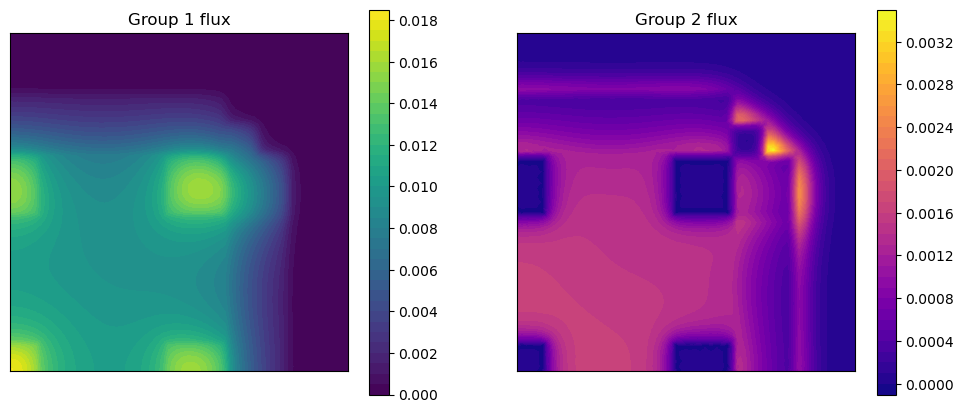

In [1]:
from data_generation import DiffusionModel
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.stats import qmc
from time import time

diff_model = DiffusionModel()
diff_model.set_parameters(path_mgxs='MGXS/')
diff_model.criticality_calculation(verbose=True)

nodes = diff_model.domain.geometry.x

cmaps = ['viridis', 'plasma']

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for g in range(diff_model.neutronics_param['Energy Groups']):
    phi_g = diff_model.critical_flux[g].x.array[:]
    c = axs[g].tricontourf(nodes[:, 0], nodes[:, 1], phi_g, levels=40, cmap=cmaps[g])
    axs[g].set_title(f'Group {g+1} flux')
    fig.colorbar(c, ax=axs[g])

    axs[g].set_aspect('equal', 'box')
    axs[g].set_xticks([])
    axs[g].set_yticks([])

Let's assemble the transient problem and store nodes

In [2]:
diff_model.define_transient_pb(dt=5e-3)

T_final = 4

# Store nodes
nodes = diff_model.extract_nodes()
import pickle
# pickle.dump(nodes, open('../../NuSHRED_Datasets/D5/nodes.pkl', 'wb'))

## Parametric Ramp Insertion of Reactivity
The absorption cross section in region 1 is decreased according to the following law
$$
\Sigma_{a,2}(\mathbf{x},t) = 
\left\{
\begin{array}{ll}
\Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ 1+(\delta\Sigma - 1)\cdot \frac{t}{t_{*}} \right] & \text{ for } t \leq t_{*}\\
\Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ \delta\Sigma \right]  &\text{ for } t > t_{*}
\end{array}
\right.

$$
given $\mathbf{x}\in\Omega_1$ and $t_{end}=1s$.

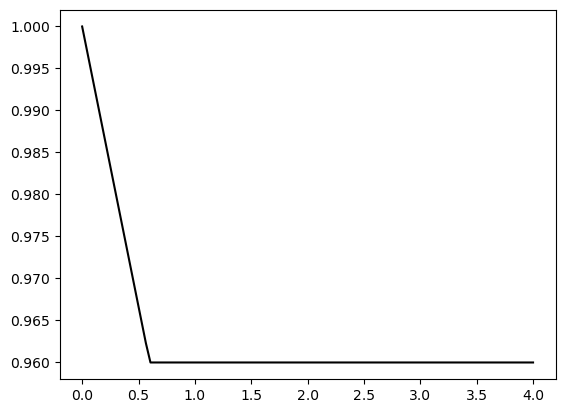

In [3]:
t_example = np.linspace(0, T_final, 100)

# Ramp
delta_sigma_example = 0.96
t_star_example = 0.6
ramp_example = lambda t: np.piecewise(t, 
                                    [t <= 0, (t>0) & (t <= t_star_example), t > t_star_example],
                                    [lambda x: 1.0, lambda x: x/t_star_example * (delta_sigma_example-1)+1, lambda x: delta_sigma_example])    

plt.plot(t_example, ramp_example(t_example), 'k-')

Generate the parameters

Text(0, 0.5, 'ramp end time (s)')

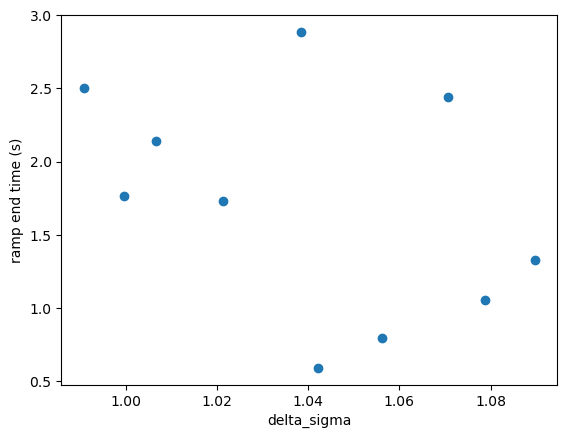

In [4]:
n_samples = 10
lb_params = np.array([0.98, 0.5])
ub_params = np.array([1.10, 3.0])

# Create LHS sampler
sampler = qmc.LatinHypercube(d=2, seed=42)
sample = sampler.random(n=n_samples)

# Scale to bounds
parameters = qmc.scale(sample, lb_params, ub_params) # First Column: delta_sigma, Second Column: end ramp time n

plt.scatter(parameters[:,0], parameters[:,1])
plt.xlabel('delta_sigma')
plt.ylabel('ramp end time (s)')

### Diffusion

In [5]:
parametric_snapshots = dict()
parametric_integral_qties = list()
cpu_times = list()

for i, delta_sigma in enumerate(parameters[:,0]):

    print(f"Solving transient for sample {i+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}")
    print(' ')

    ramp = lambda t: np.piecewise(t, 
                                    [t <= 0, (t>0) & (t <= parameters[i,1]), t > parameters[i,1]],
                                    [lambda x: 1.0, lambda x: x/parameters[i,1] * (delta_sigma-1)+1, lambda x: delta_sigma])    
    

    # Solve transient with reactivity insertion
    start_time = time()
    snapshots, integral_qties, times = diff_model.solve_transient(ramp, t_end = T_final, verbose=True, save_every=5)
    cpu_times.append(time() - start_time)

    if i == 0:
        for key in snapshots.keys():
            parametric_snapshots[key] = np.zeros((n_samples, snapshots[key].shape[0], snapshots[key].shape[1]))
    
    # Store snapshots and integral quantities
    for key in snapshots.keys():
        parametric_snapshots[key][i,:,:] = snapshots[key]
    parametric_integral_qties.append(integral_qties)

    clear_output()

parametric_integral_qties = np.array(parametric_integral_qties)

Store diffusion data

In [ ]:
import os
path_snaps = '../../NuSHRED_Datasets/D5/Ramp/'
os.makedirs(path_snaps, exist_ok=True)

# Store CPU times
path_time = '../../NuSHRED_Datasets/D5/CPUTimes/Ramp/'
os.makedirs(path_time, exist_ok=True)
np.save(os.path.join(path_time, 'cpu_times_diffusion.npy'), np.array(cpu_times))

# Store diffusion data
np.savez_compressed(os.path.join(path_snaps, 'parameters_diffusion.npz'), 
                    parameters=parameters,
                    times=times,
                    integral_qties=parametric_integral_qties)

for key in parametric_snapshots.keys():
    print(f'Storing snapshots for {key}')
    np.savez_compressed(os.path.join(path_snaps, f'snapshots_diffusion_{key}.npz'), 
                        snapshots=parametric_snapshots[key])

### Point Kinetics

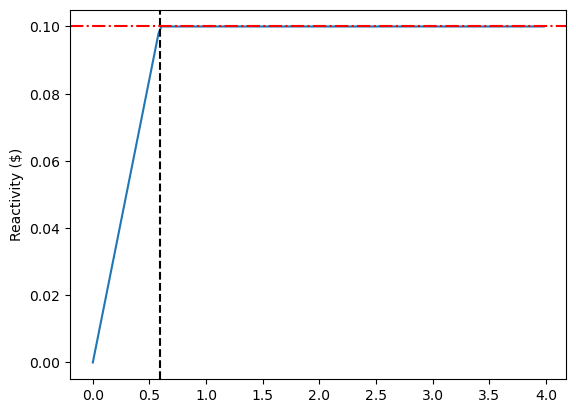

In [6]:
ii = -1
rho_example = lambda t: np.piecewise(t, 
                                    [t <= 0, (t>0) & (t <= parameters[ii,1]), t > parameters[ii,1]],
                                    [lambda x: 0.0, lambda x: 0.1/parameters[ii,1] * x, lambda x: 0.1])

plt.plot(times, rho_example(times))
plt.ylabel('Reactivity ($)')
plt.axvline(parameters[ii,1], color='k', linestyle='--', label='Ramp end time')
plt.axhline(.1, color='r', linestyle='-.')

Solve PK

In [7]:
from data_generation import PointKinetics

pk_snapshots = list()
pk_cpu_times = list()

for ii, delta_sigma in enumerate(parameters[:,0]):

    print(f"Calculating PK for sample {ii+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}", end='\r')

    keff_perturb, rho_perturb = diff_model.calculate_perturbation(delta_sigma)

    rho_t_ramp = lambda t: np.piecewise(t, 
                                    [t <= 0, (t>0) & (t <= parameters[ii,1]), t > parameters[ii,1]],
                                    [lambda x: 0.0, lambda x: rho_perturb/parameters[ii,1] * x, lambda x: rho_perturb])
    
    pk = PointKinetics(path_mgxs='MGXS/', Lambda=4e-5)
    start_time = time()
    pk_snaps = pk.solve(rho_t_ramp, times)
    pk_cpu_times.append(time() - start_time)

    # Store PK snapshots
    pk_snapshots.append(pk_snaps)

    clear_output()

pk_snapshots = np.array(pk_snapshots) # shape (n_samples, n_times, n_qties)

### Comparison

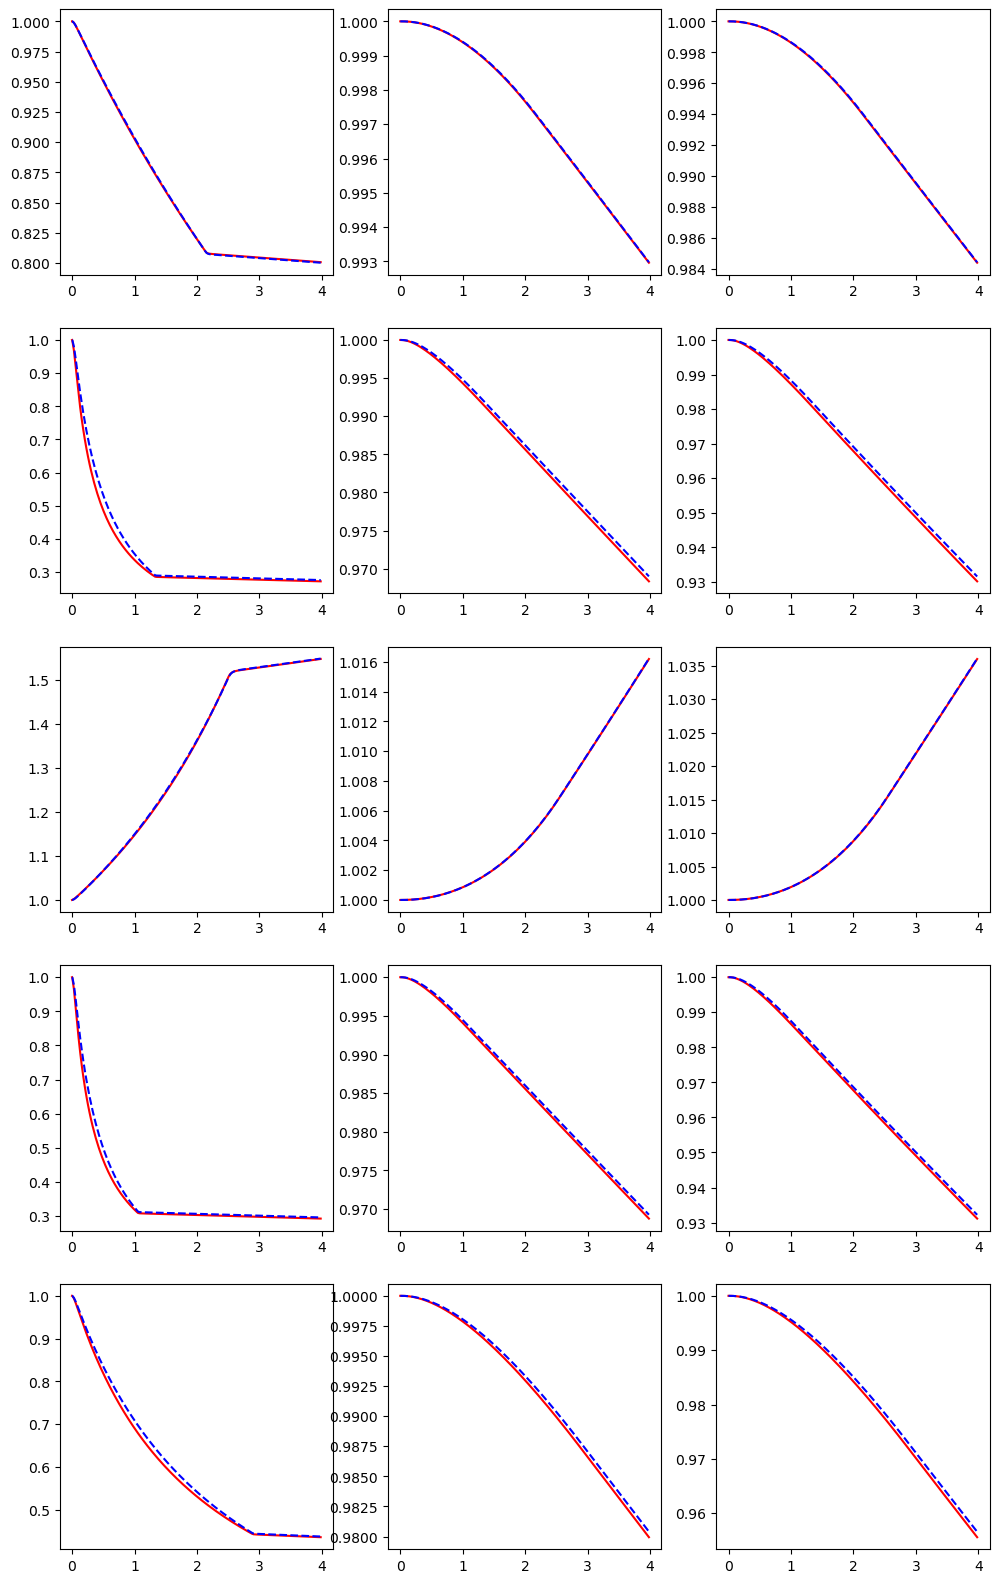

In [8]:
params_to_plot = [0,2,4,6,8]

import matplotlib.pyplot as plt
fig, axs = plt.subplots(len(params_to_plot),3, figsize=(4 * 3, 4 * len(params_to_plot)))

diff_idx = [0,3,4]

for ii, param_idx in enumerate(params_to_plot):
    for jj in range(3):
        axs[ii, jj].plot(times, parametric_integral_qties[ii, :, diff_idx[jj]] / parametric_integral_qties[ii, :, diff_idx[jj]][0], 
                         'r-', label='Diffusion')
        axs[ii, jj].plot(times, pk_snapshots[ii, :, jj] / pk_snapshots[ii, 0, jj], 
                         'b--', label='Point Kinetics')

## Parametric Sinusoidal Insertion of Reactivity
The absorption cross section in region 1 is decreased according to the following law
$$
\Sigma_{a,2}(\mathbf{x},t) = \Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ 1 + \frac{\delta\Sigma - 1}{2}\cdot \left(1 - \cos\left(\frac{2\pi t}{T}\right)\right) \right]
$$
given $\mathbf{x}\in\Omega_1$ and $T=1s$.

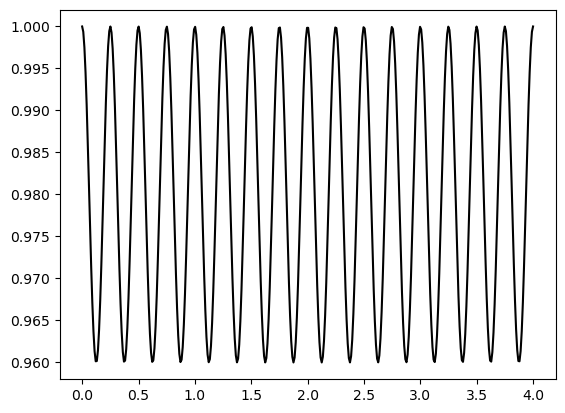

In [9]:
t_example = np.linspace(0, T_final, 400)

delta_sigma_example = 0.96
period_example = 0.25
sinusoidal_example = lambda t: 1 + (delta_sigma_example - 1) / 2 * (1 - np.cos(2 * np.pi * t / period_example))

plt.plot(t_example, sinusoidal_example(t_example), 'k-')

Sample the parameters

Text(0, 0.5, 'Period (s)')

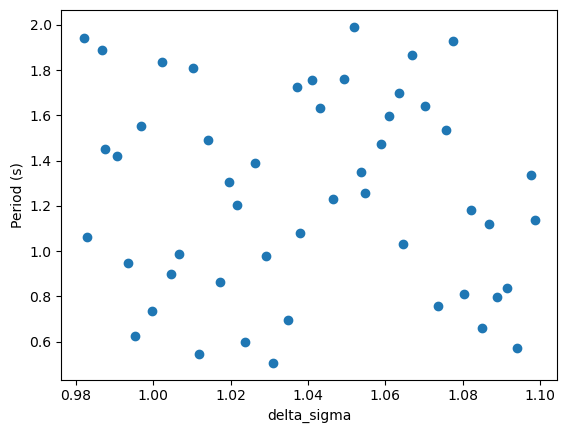

In [10]:
n_samples = 50
lb_params = np.array([0.98, 0.5])
ub_params = np.array([1.10, 2])

# Create LHS sampler
sampler = qmc.LatinHypercube(d=2, seed=42)
sample = sampler.random(n=n_samples)

# Scale to bounds
parameters = qmc.scale(sample, lb_params, ub_params) # First Column: delta_sigma, Second Column: end ramp time n

plt.scatter(parameters[:,0], parameters[:,1])
plt.xlabel('delta_sigma')
plt.ylabel('Period (s)')

### Diffusion

In [ ]:
from time import time

parametric_snapshots = dict()
parametric_integral_qties = list()
cpu_times = list()

for i, delta_sigma in enumerate(parameters[:,0]):

    print(f"Solving transient for sample {i+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}")
    print(' ')

    sinusoidal = lambda t: 1 + (delta_sigma - 1) / 2 * (1 - np.cos(2 * np.pi * t / parameters[i,1]))
    
    # Solve transient with step reactivity insertion
    start_time = time()
    snapshots, integral_qties, times = diff_model.solve_transient(sinusoidal, t_end = T_final, verbose=True, save_every=5)
    cpu_times.append(time() - start_time)

    if i == 0:
        for key in snapshots.keys():
            parametric_snapshots[key] = np.zeros((n_samples, snapshots[key].shape[0], snapshots[key].shape[1]))
    
    # Store snapshots and integral quantities
    for key in snapshots.keys():
        parametric_snapshots[key][i,:,:] = snapshots[key]
    parametric_integral_qties.append(integral_qties)

    clear_output()

parametric_integral_qties = np.array(parametric_integral_qties)

Solving transient for sample 22/50 with delta_sigma = 1.04312
 


Store diffusion data

In [ ]:
import os
path_snaps = '../../NuSHRED_Datasets/D5/Sinusoidal/'
os.makedirs(path_snaps, exist_ok=True)

# Store CPU times   
path_time = '../../NuSHRED_Datasets/D5/CPUTimes/Sinusoidal/'
os.makedirs(path_time, exist_ok=True)
np.save(os.path.join(path_time, 'cpu_times_diffusion.npy'), np.array(cpu_times))

# Store diffusion data
np.savez_compressed(os.path.join(path_snaps, 'parameters_diffusion.npz'), 
                    parameters=parameters,
                    times=times,
                    integral_qties=parametric_integral_qties)

for key in parametric_snapshots.keys():
    print(f'Storing snapshots for {key}')
    np.savez_compressed(os.path.join(path_snaps, f'snapshots_diffusion_{key}.npz'), 
                        snapshots=parametric_snapshots[key])

### Point Kinetics

In [ ]:
rho_example = lambda t: 0.1 / 2 * (1 - np.cos(2 * np.pi * t / parameters[i,1]))

plt.plot(times, rho_example(times))
plt.ylabel('Reactivity ($)')

Let us solve the PK equations for the sinusoidal reactivity insertion

In [ ]:
from data_generation import PointKinetics

pk_snapshots = list()
pk_cpu_times = list()

for ii, delta_sigma in enumerate(parameters[:,0]):

    print(f"Calculating PK for sample {ii+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}", end='\r')

    keff_perturb, rho_perturb = diff_model.calculate_perturbation(delta_sigma)

    rho_t_sinusoidal = lambda t: rho_perturb / 2 * (1 - np.cos(2 * np.pi * t / parameters[ii,1]))
    
    pk = PointKinetics(path_mgxs='MGXS/', Lambda=4e-5)
    start_time = time()
    pk_snaps = pk.solve(rho_t_sinusoidal, times)
    pk_cpu_times.append(time() - start_time)

    # Store PK snapshots
    pk_snapshots.append(pk_snaps)

    clear_output()

pk_snapshots = np.array(pk_snapshots) # shape (n_samples, n_times, n_qties)

Store PK solution

In [ ]:
# Store CPU times
np.save(os.path.join(path_time, 'cpu_times_pk.npy'), np.array(pk_cpu_times))

np.savez_compressed(os.path.join(path_snaps, 'snapshots_pk.npz'),
                    snapshots=pk_snapshots)

### Comparison

In [ ]:
# params_to_plot = [0, 5, 10, 15, 20, 25]

# import matplotlib.pyplot as plt
# fig, axs = plt.subplots(len(params_to_plot),3, figsize=(4 * 3, 4 * len(params_to_plot)))

# diff_idx = [0,3,4]

# for ii, param_idx in enumerate(params_to_plot):
#     for jj in range(3):
#         axs[ii, jj].plot(times, parametric_integral_qties[ii, :, diff_idx[jj]] / parametric_integral_qties[ii, :, diff_idx[jj]][0], 
#                          'r-', label='Diffusion')
#         axs[ii, jj].plot(times, pk_snapshots[ii, :, jj] / pk_snapshots[ii, 0, jj], 
#                          'b--', label='Point Kinetics')
        
# plt.tight_layout()

## Parametric Trapezoidal Insertion of Reactivity
The absorption cross section in region 1 is decreased according to the following law
$$
\Sigma_{a,2}(\mathbf{x},t) = 
\left\{
\begin{array}{ll}
\Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ 1 + (\delta\Sigma - 1) \cdot \frac{t}{T_{rise}} \right] & \text{ for } t \leq T_{rise}\\
\Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ \delta\Sigma \right] & \text{ for } T_{rise} < t \leq T_{fall}\\
\Sigma_{a,2}^{0}(\mathbf{x})\cdot \left[ 1 + (\delta\Sigma - 1) \cdot \frac{T_{final} - t}{T_{final} - T_{fall}} \right] & \text{ for } t > T_{fall}
\end{array}
\right.
$$
given $\mathbf{x}\in\Omega_1$, $T_{final}=1s$,

In [ ]:
t_example = np.linspace(0, T_final, 400)

# Trapezoidal
delta_sigma_example = 0.96
t_rise_example = 0.3
t_fall_example = 0.5

trapz_example = lambda t: np.piecewise(t,
                                    [t <= 0, (t>0) & (t <= t_rise_example), (t>t_rise_example) & (t <= t_fall_example), t > t_fall_example],
                                    [lambda x: 1.0, 
                                     lambda x: x/t_rise_example * (delta_sigma_example-1)+1,
                                     lambda x: delta_sigma_example,
                                     lambda x: -(delta_sigma_example-1)/(T_final - t_fall_example) * (x - t_fall_example) + delta_sigma_example])

plt.plot(t_example, trapz_example(t_example), 'k-')

Generation of the parameters

In [ ]:
n_samples = 50
lb_params = np.array([0.98, 0.2])
ub_params = np.array([1.10, 3])

# Create LHS sampler
sampler = qmc.LatinHypercube(d=2, seed=42)
sample = sampler.random(n=n_samples)

# Scale to bounds
parameters = qmc.scale(sample, lb_params, ub_params) # First Column: delta_sigma, Second Column: end ramp time n

plt.scatter(parameters[:,0], parameters[:,1])
plt.xlabel('delta_sigma')
plt.ylabel('rise ramp end time (s)')

### Diffusion

In [ ]:
parametric_snapshots = dict()
parametric_integral_qties = list()
cpu_times = list()

for i, delta_sigma in enumerate(parameters[:,0]):

    print(f"Solving transient for sample {i+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}")
    print(' ')

    trapz = lambda t: np.piecewise(t,
                                    [t <= 0, (t>0) & (t <= parameters[i,1]), (t>parameters[i,1]) & (t <= 0.8 * T_final), t > 0.8 * T_final],
                                    [lambda x: 1.0, 
                                     lambda x: x/parameters[i,1] * (delta_sigma-1)+1,
                                     lambda x: delta_sigma,
                                     lambda x: -(delta_sigma-1)/(T_final - 0.8 * T_final) * (x - 0.8 * T_final) + delta_sigma])
    
    # Solve transient with reactivity insertion
    start_time = time()
    snapshots, integral_qties, times = diff_model.solve_transient(trapz, t_end = T_final, verbose=True, save_every=5)
    cpu_times.append(time() - start_time)

    if i == 0:
        for key in snapshots.keys():
            parametric_snapshots[key] = np.zeros((n_samples, snapshots[key].shape[0], snapshots[key].shape[1]))
    # Store snapshots and integral quantities
    for key in snapshots.keys():
        parametric_snapshots[key][i,:,:] = snapshots[key]
    parametric_integral_qties.append(integral_qties)

    clear_output()

parametric_integral_qties = np.array(parametric_integral_qties)

Store diffusion data

In [ ]:
import os
path_snaps = '../../NuSHRED_Datasets/D5/Trapz/'
os.makedirs(path_snaps, exist_ok=True)

# Store CPU times
path_time = '../../NuSHRED_Datasets/D5/CPUTimes/Trapz/'
os.makedirs(path_time, exist_ok=True)
np.save(os.path.join(path_time, 'cpu_times_diffusion.npy'), np.array(cpu_times))

# Store diffusion data
np.savez_compressed(os.path.join(path_snaps, 'parameters_diffusion.npz'), 
                    parameters=parameters,
                    times=times,
                    integral_qties=parametric_integral_qties)

for key in parametric_snapshots.keys():
    print(f'Storing snapshots for {key}')
    np.savez_compressed(os.path.join(path_snaps, f'snapshots_diffusion_{key}.npz'), 
                        snapshots=parametric_snapshots[key])

### Point Kinetics

In [ ]:
rho_example = lambda t: np.piecewise(t,
                                    [t <= 0, (t>0) & (t <= t_rise_example), (t>t_rise_example) & (t <= t_fall_example), t > t_fall_example],
                                    [lambda x: 0.0, 
                                     lambda x: 0.1 / t_rise_example * x,
                                     lambda x: 0.1,
                                     lambda x: -0.1/(T_final - t_fall_example) * (x - t_fall_example) + 0.1])

plt.plot(times, rho_example(times))
plt.ylabel('Reactivity ($)')
plt.axvline(t_rise_example, color='k', linestyle='--', label='Ramp rise end time')
plt.axvline(t_fall_example, color='k', linestyle='-.', label='Ramp fall end time')
plt.axhline(.1, color='r', linestyle='-.')

Solve PK

In [ ]:
from data_generation import PointKinetics

pk_snapshots = list()
pk_cpu_times = list()

for ii, delta_sigma in enumerate(parameters[:,0]):

    print(f"Calculating PK for sample {ii+1}/{n_samples} with delta_sigma = {delta_sigma:.5f}", end='\r')

    keff_perturb, rho_perturb = diff_model.calculate_perturbation(delta_sigma)

    rho_t_trapz = lambda t: np.piecewise(t,
                                    [t <= 0, (t>0) & (t <= parameters[ii,1]), (t>parameters[ii,1]) & (t <= 0.8 * T_final), t > 0.8 * T_final],
                                    [lambda x: 0.0, 
                                     lambda x: rho_perturb / parameters[ii,1] * x,
                                     lambda x: rho_perturb,
                                     lambda x: -rho_perturb/(T_final - 0.8 * T_final) * (x - 0.8 * T_final) + rho_perturb])
    
    pk = PointKinetics(path_mgxs='MGXS/', Lambda=4e-5)
    start_time = time()
    pk_snaps = pk.solve(rho_t_trapz, times)
    pk_cpu_times.append(time() - start_time)

    # Store PK snapshots
    pk_snapshots.append(pk_snaps)

    clear_output()

pk_snapshots = np.array(pk_snapshots) # shape (n_samples, n_times, n_qties)

Stoke PK

In [ ]:
np.savez_compressed(os.path.join(path_snaps, 'snapshots_pk.npz'),
                    snapshots=pk_snapshots)

# Store CPU times
np.save(os.path.join(path_time, 'cpu_times_pk.npy'), np.array(pk_cpu_times))

### Comparison

In [ ]:
# params_to_plot = [0, 5, 15, 25, 40]

# import matplotlib.pyplot as plt
# fig, axs = plt.subplots(len(params_to_plot),3, figsize=(4 * 3, 4 * len(params_to_plot)))

# diff_idx = [0,3,4]

# for ii, param_idx in enumerate(params_to_plot):
#     for jj in range(3):
#         axs[ii, jj].plot(times, parametric_integral_qties[ii, :, diff_idx[jj]] / parametric_integral_qties[ii, :, diff_idx[jj]][0], 
#                          'r-', label='Diffusion')
#         axs[ii, jj].plot(times, pk_snapshots[ii, :, jj] / pk_snapshots[ii, 0, jj], 
#                          'b--', label='Point Kinetics')
        
# plt.tight_layout()